# Librerias

In [1]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import re
import causalidad as cs

Initializing causalidad package...
causalidad package initialized successfully.


# Lectura de datos

In [2]:
df_icare = pd.read_csv(r"C:\Users\afpue\OneDrive\Documentos\GitHub\causalidad\Codigo\df_icare_260226.csv")

# Funciones

## Calcular el ATE

In [3]:
cols = ['actfreq_sq001', 'recgov_sq001']

df_icare[cols] = df_icare[cols].apply(lambda x: (x == 1).astype(int))
resultado = cs.calcular_ate(
    df=df_icare,
    resultado='actfreq_sq001',
    tratamiento='recgov_sq001',
    covariables=['sex', 'age', 'edu']
)

if resultado is not None:
    print(f"ATE (diferencia de medias): {resultado['ate_diff']:.4f}")
    print(f"ATE (regresión ajustada):   {resultado['ate_reg']:.4f} (p-valor: {resultado['p_valor_reg']:.4f})")
    print(f"N tratados: {resultado['n_tratados']}, N controles: {resultado['n_controles']}")

ATE (diferencia de medias): 0.4244
ATE (regresión ajustada):   0.4120 (p-valor: 0.0000)
N tratados: 1645, N controles: 18


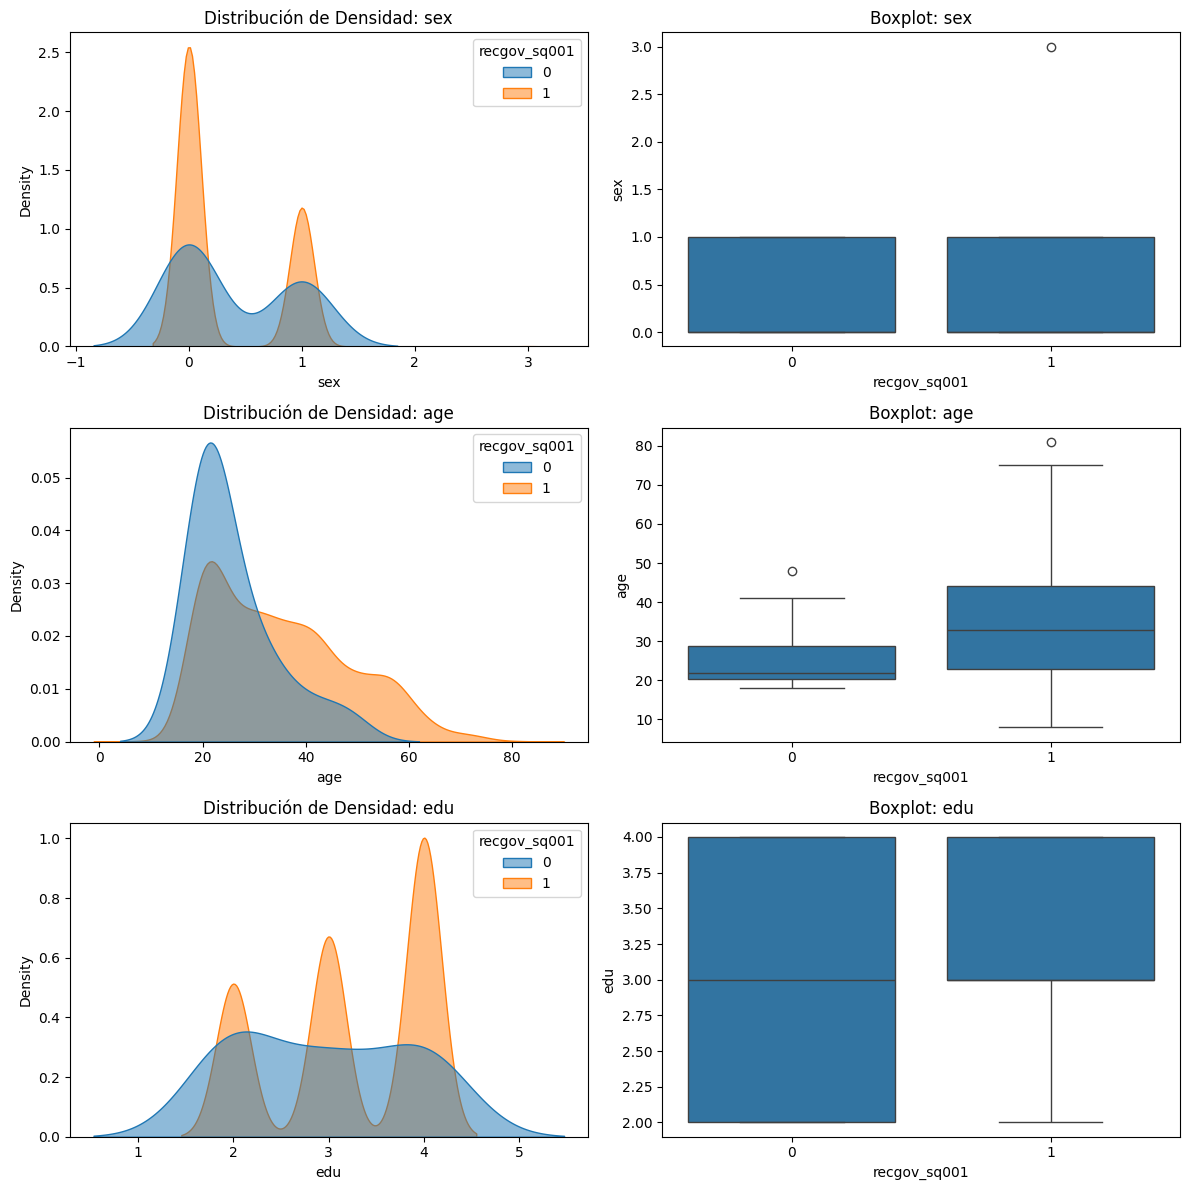

,Covariable,Tratados (Media ± SD),Controles (Media ± SD),p-valor (Prueba de Medias),SMD,Balanceado
0,sex,0.32 ± 0.47,0.39 ± 0.50,0.5581,0.1460,Sí
1,age,35.21 ± 13.39,25.83 ± 8.31,0.0002,0.8410,No
2,edu,3.22 ± 0.80,2.94 ± 0.87,0.1939,0.3332,Sí


In [4]:
cs.visualizar_balance(
    df=df_icare,
    tratamiento='recgov_sq001',
    covariables=['sex', 'age', 'edu']
)

In [5]:
import re
import pandas as pd

# 1. Identificar sufijos de las columnas disponibles
sufijos = sorted([re.search(r'sq(\d+)', col).group(1) 
                  for col in df_icare.columns if col.startswith('actfreq_sq')])

lista_resultados = []

# 2. Iterar y recolectar datos
for num in sufijos:
    col_resultado = f'actfreq_sq{num}'
    col_tratamiento = f'recgov_sq{num}'
    
    if col_tratamiento in df_icare.columns:
        # Limpieza rápida para asegurar formato 0/1
        df_temp = df_icare[[col_resultado, col_tratamiento, 'sex', 'age', 'edu']].copy().dropna()
        df_temp[col_resultado] = (df_temp[col_resultado] == 1).astype(int)
        df_temp[col_tratamiento] = (df_temp[col_tratamiento] == 1).astype(int)
        
        # Llamada a tu función de ATE
        res = cs.calcular_ate(
            df=df_temp,
            resultado=col_resultado,
            tratamiento=col_tratamiento,
            covariables=['sex', 'age', 'edu']
        )
        
        # Guardar en la lista si se pudo calcular
        if res is not None:
            lista_resultados.append({
                'ID': num,
                'Variable Resultado': col_resultado,
                'Tratamiento': col_tratamiento,
                'ATE (Diff)': round(res['ate_diff'], 4),
                'ATE (Reg)': round(res['ate_reg'], 4),
                'p-valor (Reg)': round(res['p_valor_reg'], 4),
                'N Tratados': res['n_tratados'],
                'N Controles': res['n_controles']
            })

# 3. Crear DataFrame y mostrar tabla final
df_resumen = pd.DataFrame(lista_resultados)
print(df_resumen.to_string(index=False))

 ID Variable Resultado  Tratamiento  ATE (Diff)  ATE (Reg)  p-valor (Reg)  N Tratados  N Controles
001      actfreq_sq001 recgov_sq001      0.4244     0.4120         0.0000        1645           18
002      actfreq_sq002 recgov_sq002      0.3711     0.3775         0.0000        1537           93
003      actfreq_sq003 recgov_sq003      0.6041     0.6088         0.0000        1503          103
004      actfreq_sq004 recgov_sq004      0.5799     0.5659         0.0000        1534           52
005      actfreq_sq005 recgov_sq005      0.4695     0.4433         0.0000         819          561
006      actfreq_sq006 recgov_sq006      0.4995     0.4789         0.0000         296          959
007      actfreq_sq007 recgov_sq007      0.3322     0.3217         0.0000        1596           30
008      actfreq_sq008 recgov_sq008      0.1880     0.1880         0.0000        1584           30
010      actfreq_sq010 recgov_sq010     -0.0784    -0.0939         0.4372         969            5
012      a

In [6]:
df_icare

,submitdate,Wave,startdate,datestamp,sex,age,edu,emplstat_sq001,emplstat_sq002,emplstat_sq003,...,govmeas_6,govmeas_7,govmeas_8,govmeas_9,govmeas_10,livekidsm,livead,livekids,actfreq_sq009,actfreq_sq025
0,2020-03-31 11:09:05.000,1,2020-03-31 10:34:43.997,2020-03-31 11:09:05.000,0,42.0,4.0,0,0,0,...,3.0,10.0,1.0,5.0,2.0,0.0,0.0,0.0,1.0,1.0
1,2020-03-31 11:15:36.996,1,2020-03-31 10:36:07.001,2020-03-31 11:15:36.996,0,19.0,2.0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,1.0,3.0,1.0,NaN,1.0
2,2020-03-31 13:27:39.004,1,2020-03-31 12:57:36.000,2020-03-31 13:27:39.004,0,20.0,2.0,0,0,0,...,9.0,6.0,NaN,NaN,NaN,1.0,3.0,1.0,1.0,1.0
3,2020-03-31 18:23:24.000,1,2020-03-31 17:57:09.999,2020-03-31 18:23:24.000,0,50.0,3.0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,1.0,2.0,1.0,1.0,1.0
4,2020-03-31 18:24:59.999,1,2020-03-31 18:12:30.997,2020-03-31 18:24:59.999,0,40.0,4.0,0,0,0,...,5.0,9.0,NaN,NaN,NaN,2.0,1.0,2.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1662,2020-08-13 15:43:06.997,5,2020-08-13 15:10:42.004,2020-08-13 15:43:06.997,1,21.0,3.0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0,1.0,1.0
1663,2020-08-14 19:41:16.996,5,2020-08-14 19:18:04.997,2020-08-14 19:41:16.996,0,32.0,4.0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0,NaN,1.0
1664,2020-08-15 12:40:38.001,5,2020-08-15 12:23:53.998,2020-08-15 12:40:38.001,0,34.0,4.0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,1.0
1665,2020-08-15 13:45:00.996,5,2020-08-15 13:25:00.002,2020-08-15 13:45:00.996,0,25.0,3.0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,5.0,0.0,NaN,1.0


## Balancear

In [7]:
# Para matching
df_match = cs.balancear_propensity(df_icare, 'recgov_sq001', 'actfreq_sq001', 
                                     ['sex','age','edu'], metodo='matched', replacement=False)

ate_match = cs.calcular_ate(df_match, 'actfreq_sq001', 'recgov_sq001', covariables=['sex','age','edu'])

if ate_match is not None:
    print(f"ATE (diferencia de medias): {ate_match['ate_diff']:.4f}")
    print(f"ATE (regresión ajustada):   {ate_match['ate_reg']:.4f} (p-valor: {ate_match['p_valor_reg']:.4f})")
    print(f"N tratados: {ate_match['n_tratados']}, N controles: {ate_match['n_controles']}")

# Para subclassification
df_sub = cs.balancear_propensity(df_icare, 'recgov_sq001', 'actfreq_sq001', 
                                   ['sex','age','edu'], metodo='subclassification', n_subclases=5)

ate_sub = cs.calcular_ate(df_sub, 'actfreq_sq001', 'recgov_sq001', covariables=['sex','age','edu'])

if ate_sub is not None:
    print(f"ATE (diferencia de medias): {ate_sub['ate_diff']:.4f}")
    print(f"ATE (regresión ajustada):   {ate_sub['ate_reg']:.4f} (p-valor: {ate_sub['p_valor_reg']:.4f})")
    print(f"N tratados: {ate_sub['n_tratados']}, N controles: {ate_sub['n_controles']}")

ATE (diferencia de medias): 0.4444
ATE (regresión ajustada):   0.4253 (p-valor: 0.0062)
N tratados: 18, N controles: 18
ATE (diferencia de medias): 0.4244
ATE (regresión ajustada):   0.4120 (p-valor: 0.0000)
N tratados: 1645, N controles: 18


In [9]:
import re
import pandas as pd

# 1. Identificar sufijos de las columnas disponibles
sufijos = sorted([re.search(r'sq(\d+)', col).group(1) 
                  for col in df_icare.columns if col.startswith('actfreq_sq')])

resultados_balanceados = []

# 2. Iterar sobre todos los pares
for num in sufijos:
    col_resultado = f'actfreq_sq{num}'
    col_tratamiento = f'recgov_sq{num}'
    
    # Verificar que el tratamiento exista en el dataframe
    if col_tratamiento in df_icare.columns:
        
        # Preparar los datos eliminando nulos y asegurando formato binario 0/1
        df_temp = df_icare[[col_resultado, col_tratamiento, 'sex', 'age', 'edu']].dropna().copy()
        df_temp[col_resultado] = (df_temp[col_resultado] == 1).astype(int)
        df_temp[col_tratamiento] = (df_temp[col_tratamiento] == 1).astype(int)
        
        # Diccionario base para guardar la fila
        fila = {
            'ID': num,
            'Variable Resultado': col_resultado,
            'Tratamiento': col_tratamiento
        }
        
        # --- A. METODO MATCHING ---
        df_match = cs.balancear_propensity(
            df=df_temp, 
            tratamiento=col_tratamiento, 
            resultado=col_resultado, 
            covariables=['sex', 'age', 'edu'], 
            metodo='matched', 
            replacement=True
        )
        
        if df_match is not None:
            ate_match = cs.calcular_ate(df_match, col_resultado, col_tratamiento, ['sex', 'age', 'edu'])
            if ate_match is not None:
                fila['Match ATE (Diff)'] = round(ate_match['ate_diff'], 4)
                fila['Match ATE (Reg)'] = round(ate_match['ate_reg'], 4)
                fila['Match p-valor'] = round(ate_match['p_valor_reg'], 4)
                fila['Match N (T/C)'] = f"{ate_match['n_tratados']} / {ate_match['n_controles']}"
        
        # --- B. METODO SUBCLASIFICACIÓN ---
        df_sub = cs.balancear_propensity(
            df=df_temp, 
            tratamiento=col_tratamiento, 
            resultado=col_resultado, 
            covariables=['sex', 'age', 'edu'], 
            metodo='subclassification', 
            n_subclases=5
        )
        
        if df_sub is not None:
            ate_sub = cs.calcular_ate(df_sub, col_resultado, col_tratamiento, ['sex', 'age', 'edu'])
            if ate_sub is not None:
                fila['Sub ATE (Diff)'] = round(ate_sub['ate_diff'], 4)
                fila['Sub ATE (Reg)'] = round(ate_sub['ate_reg'], 4)
                fila['Sub p-valor'] = round(ate_sub['p_valor_reg'], 4)
                fila['Sub N (T/C)'] = f"{ate_sub['n_tratados']} / {ate_sub['n_controles']}"
        
        # Añadir la fila a la lista general
        resultados_balanceados.append(fila)

# 3. Mostrar la tabla final
df_resultados_finales = pd.DataFrame(resultados_balanceados)
print("=== RESULTADOS ATE BALANCEADOS ===")
print(df_resultados_finales.to_string(index=False))

=== RESULTADOS ATE BALANCEADOS ===
 ID Variable Resultado  Tratamiento  Match ATE (Diff)  Match ATE (Reg)  Match p-valor Match N (T/C)  Sub ATE (Diff)  Sub ATE (Reg)  Sub p-valor Sub N (T/C)
001      actfreq_sq001 recgov_sq001            0.3356           0.3320         0.0000   1645 / 1645          0.4244         0.4120       0.0000   1645 / 18
002      actfreq_sq002 recgov_sq002            0.3995           0.4006         0.0000   1537 / 1537          0.3711         0.3775       0.0000   1537 / 93
003      actfreq_sq003 recgov_sq003            0.6314           0.6293         0.0000   1503 / 1503          0.6041         0.6088       0.0000  1503 / 103
004      actfreq_sq004 recgov_sq004            0.5958           0.5939         0.0000   1534 / 1534          0.5799         0.5659       0.0000   1534 / 52
005      actfreq_sq005 recgov_sq005            0.4750           0.4703         0.0000     819 / 819          0.4695         0.4433       0.0000   819 / 561
006      actfreq_sq006 recgov

# Con mas variables

In [14]:
import re
import pandas as pd

# 1. Definir la lista IDEAL de covariables a usar
covariables_ideales = [
    'sex', 'age', 'edu', 'hoinc',            
    'phyhe', 'menthe',                       
    'cempstat_sq001', 'cempstat_sq002',      
    'cempstat_sq003', 'cempstat_sq004', 
    'cempstat_sq005', 'cempstat_sq006'
]

# NUEVO: Filtrar solo las covariables que REALMENTE existen en tu df_icare
covariables_lista = [cov for cov in covariables_ideales if cov in df_icare.columns]
print(f"Covariables detectadas y a utilizar: {covariables_lista}\n")

# 2. Identificar sufijos de las columnas disponibles
sufijos = sorted([re.search(r'sq(\d+)', col).group(1) 
                  for col in df_icare.columns if col.startswith('actfreq_sq')])

resultados_balanceados = []

# 3. Iterar sobre todos los pares
for num in sufijos:
    col_resultado = f'actfreq_sq{num}'
    col_tratamiento = f'recgov_sq{num}'
    
    if col_tratamiento in df_icare.columns and col_resultado in df_icare.columns:
        
        columnas_necesarias = [col_resultado, col_tratamiento] + covariables_lista
        df_temp = df_icare[columnas_necesarias].dropna().copy()
        
        # Binarizar: 1 si cumple la condición, 0 de lo contrario
        df_temp[col_resultado] = (df_temp[col_resultado] == 1).astype(int)
        df_temp[col_tratamiento] = (df_temp[col_tratamiento] == 1).astype(int)
        
        fila = {
            'ID': num,
            'Variable Resultado': col_resultado,
            'Tratamiento': col_tratamiento
        }
        
        # --- A. METODO MATCHING ---
        df_match = cs.balancear_propensity(
            df=df_temp, 
            tratamiento=col_tratamiento, 
            resultado=col_resultado, 
            covariables=covariables_lista, 
            metodo='matched', 
            replacement=False
        )
        
        if df_match is not None:
            ate_match = cs.calcular_ate(df_match, col_resultado, col_tratamiento, covariables_lista)
            if ate_match is not None:
                fila['Match ATE (Diff)'] = round(ate_match['ate_diff'], 4)
                fila['Match ATE (Reg)'] = round(ate_match['ate_reg'], 4)
                fila['Match p-valor'] = round(ate_match['p_valor_reg'], 4)
                fila['Match N (T/C)'] = f"{ate_match['n_tratados']} / {ate_match['n_controles']}"
        
        # --- B. METODO SUBCLASIFICACIÓN ---
        df_sub = cs.balancear_propensity(
            df=df_temp, 
            tratamiento=col_tratamiento, 
            resultado=col_resultado, 
            covariables=covariables_lista, 
            metodo='subclassification', 
            n_subclases=5
        )
        
        if df_sub is not None:
            ate_sub = cs.calcular_ate(df_sub, col_resultado, col_tratamiento, covariables_lista)
            if ate_sub is not None:
                fila['Sub ATE (Diff)'] = round(ate_sub['ate_diff'], 4)
                fila['Sub ATE (Reg)'] = round(ate_sub['ate_reg'], 4)
                fila['Sub p-valor'] = round(ate_sub['p_valor_reg'], 4)
                fila['Sub N (T/C)'] = f"{ate_sub['n_tratados']} / {ate_sub['n_controles']}"
        
        resultados_balanceados.append(fila)

# 4. Mostrar la tabla final
df_resultados_finales = pd.DataFrame(resultados_balanceados)
print("=== RESULTADOS ATE BALANCEADOS ===")
print(df_resultados_finales.to_string(index=False))

Covariables detectadas y a utilizar: ['sex', 'age', 'edu', 'hoinc', 'phyhe', 'menthe']

=== RESULTADOS ATE BALANCEADOS ===
 ID Variable Resultado  Tratamiento  Match ATE (Diff)  Match ATE (Reg)  Match p-valor Match N (T/C)  Sub ATE (Diff)  Sub ATE (Reg)  Sub p-valor Sub N (T/C)
001      actfreq_sq001 recgov_sq001            0.4286           0.5174         0.0117       14 / 14          0.4111         0.3987       0.0000   1432 / 14
002      actfreq_sq002 recgov_sq002            0.3563           0.3759         0.0000       87 / 87          0.3623         0.3683       0.0000   1330 / 87
003      actfreq_sq003 recgov_sq003            0.2604           0.2717         0.0002       96 / 96          0.6111         0.6124       0.0000   1303 / 96
004      actfreq_sq004 recgov_sq004            0.5800           0.6004         0.0000       50 / 50          0.5867         0.5697       0.0000   1329 / 50
005      actfreq_sq005 recgov_sq005            0.4558           0.4266         0.0000     509 / 5

=== RELACIÓN DE COVARIABLES CON: recgov_sq001 ===
Nota: Una correlación cercana a 0 indica que la variable está balanceada de forma natural.
-------------------------------------------------------
        Covarianza  Correlación
age       0.077615     0.059293
phyhe    -0.003145    -0.053945
hoinc    -0.002977    -0.051001
menthe   -0.002321    -0.034107
sex      -0.000231    -0.004994
edu       0.000363     0.004641
-------------------------------------------------------


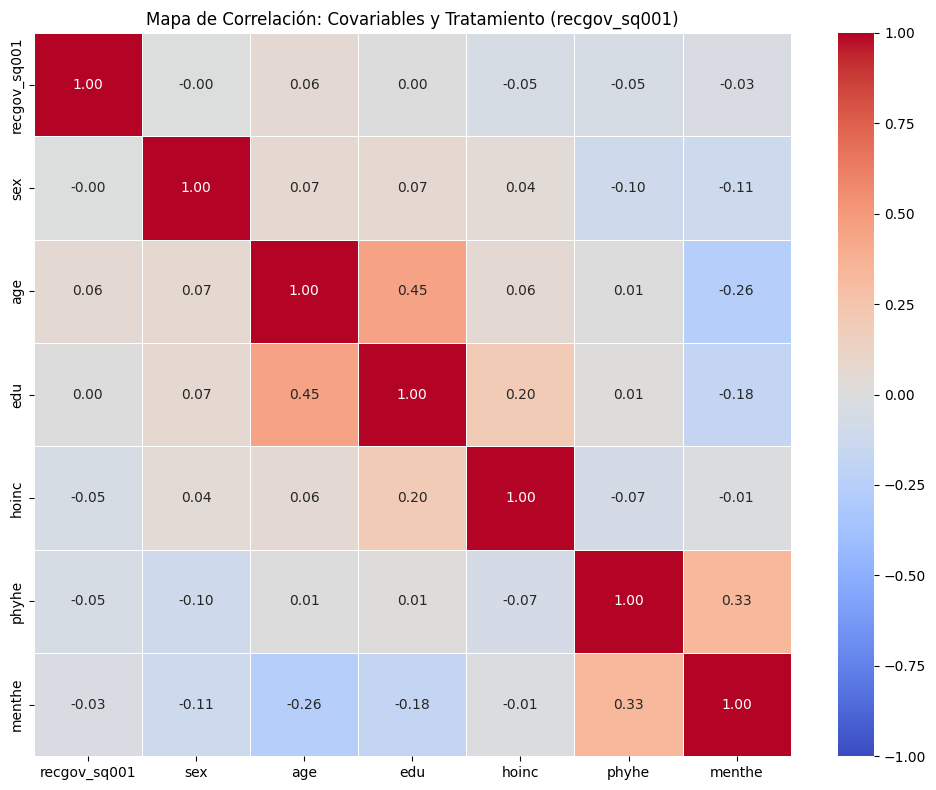

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def ver_relaciones_variables(df, tratamiento, covariables):
    """
    Calcula la covarianza y correlación de las covariables con el tratamiento,
    y genera un mapa de calor para identificar multicolinealidad.
    """
    # 1. Preparar los datos
    cols = [tratamiento] + covariables
    df_clean = df[cols].dropna().copy()
    
    # Asegurar que el tratamiento sea numérico (si estaba en bool o string)
    df_clean[tratamiento] = df_clean[tratamiento].astype(float)
    
    # 2. Calcular matrices
    matriz_cov = df_clean.cov()
    matriz_corr = df_clean.corr()
    
    # 3. Extraer solo la relación directa con la variable de TRATAMIENTO
    # Eliminamos la fila del tratamiento vs sí mismo (que siempre es cov=varianza, corr=1)
    cov_tratamiento = matriz_cov[[tratamiento]].drop(tratamiento)
    corr_tratamiento = matriz_corr[[tratamiento]].drop(tratamiento)
    
    # Unir ambas métricas en una sola tabla, ordenada por la correlación más fuerte
    relaciones = pd.concat([cov_tratamiento, corr_tratamiento], axis=1)
    relaciones.columns = ['Covarianza', 'Correlación']
    relaciones = relaciones.sort_values(by='Correlación', key=abs, ascending=False)
    
    print(f"=== RELACIÓN DE COVARIABLES CON: {tratamiento} ===")
    print("Nota: Una correlación cercana a 0 indica que la variable está balanceada de forma natural.")
    print("-" * 55)
    print(relaciones.to_string())
    print("-" * 55)
    
    # 4. Generar el Mapa de Calor (Heatmap) de la Matriz de Correlación
    plt.figure(figsize=(10, 8))
    # Usamos correlación para el gráfico porque la covarianza no tiene escala fija
    sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', center=0, fmt=".2f", 
                linewidths=0.5, vmin=-1, vmax=1)
    plt.title(f'Mapa de Correlación: Covariables y Tratamiento ({tratamiento})')
    plt.tight_layout()
    plt.show()
    
    return relaciones

# Ejemplo de uso:
relaciones = ver_relaciones_variables(df_icare, 'recgov_sq001', covariables_lista)